# Testing for the 2DInt Method for Dip, Auto, and Allo

In [1]:
import numpy as np
import dadi 
from matplotlib import pyplot as plt
import dadi.Polyploidy.Integration as PolyInt
from dadi.Polyploidy import wrightfisher as WF
import time

# Testing against dadi

In [2]:
# make a function to plot the relative difference and use 
# numpy to assert that all of the values are within a given tolerance

def compare_phis(phipoly, phidadi, edges, xlab, ylab, plotall=False):
    # plot the two phis
    if plotall: # this will plot the phi from dadi, from PolyInt, and the difference
        plt.pcolormesh(edges, edges, phipoly.T, cmap='viridis', shading='auto')
        plt.colorbar(label='Density')
        plt.xlabel(xlab)
        plt.ylabel(ylab)
        plt.title('PolyInt')
        plt.show()
    
        plt.pcolormesh(edges, edges, phidadi.T, cmap='viridis', shading='auto')
        plt.colorbar(label='Density')
        plt.xlabel(xlab)
        plt.ylabel(ylab)
        plt.title('dadi')
        plt.show()

        plt.pcolormesh(edges, edges, (phipoly.T - phidadi.T), cmap='viridis', shading='auto')
        plt.colorbar(label='Density')
        plt.xlabel(xlab)
        plt.ylabel(ylab)
        plt.title('(PolyInt - dadi)')
        plt.show()
    # what we are normally interested in is the relative difference, so we always plot that
    plt.pcolormesh(edges, edges, (phipoly.T - phidadi.T)/phidadi.T, cmap='viridis', shading='auto')
    plt.colorbar(label='Density')
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title('(PolyInt - dadi)/dadi')
    plt.show()
    
    assert np.allclose(phipoly, phidadi)



## First, we want to test against dadi for diploids

Here, we mostly want to ensure that the integration is working correctly.

Also, note that we are interested in the relative difference between the two integration methods. So, I plot the difference between the two phis divided by the phi from dadi. This should be close to the machine precision which is 1e-15, or so.

[[ 5.90781940e+08  5.90491243e+08  2.71227956e+08 ...  8.33852203e-05
   1.49333994e-04  1.30969200e-03]
 [ 5.89338214e+08 -2.82804148e+05 -1.17600829e+05 ...  1.00871728e-05
   1.80702206e-05  1.58530259e-04]
 [ 2.70698429e+08 -1.17555002e+05 -5.02684008e+04 ...  6.02914326e-06
   1.08029537e-05  9.47996832e-05]
 ...
 [ 8.34788704e-05  1.00991331e-05  6.03634419e-06 ...  1.57512751e-01
   1.98670762e-01  2.09098436e+02]
 [ 1.49510084e-04  1.80925739e-05  1.08164464e-05 ...  2.02296833e-01
   2.42022575e-01  2.09529268e+02]
 [ 1.31138361e-03  1.58747997e-04  9.49340275e-05 ...  2.08748556e+02
   2.08923332e+02  2.08738113e+02]]


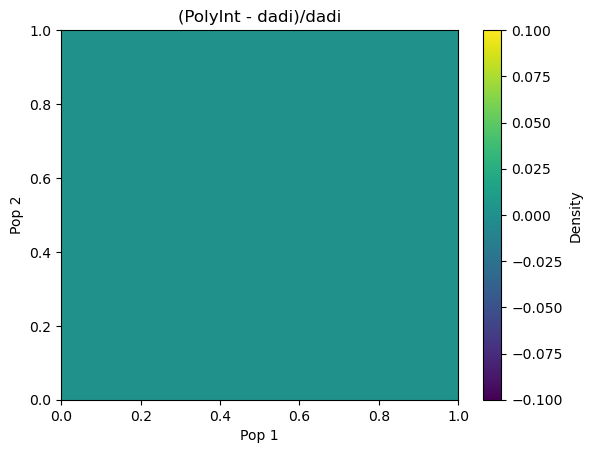

In [3]:
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx, gamma=-2)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

dipflag = PolyInt.PloidyType.DIPLOID
T = .1
gamma1 = -12
gamma2 = -12
h1 = 0.5
h2 = 0.5
m12 = .1
m21 = 0.1
sel1 = {'gamma': gamma1}
sel2 = {'gamma': gamma2}
nu1 = 1
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 1
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)

phi_poly = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=dipflag, ploidyflag2=dipflag, sel_dict1=sel1,
                           sel_dict2=sel2, nu1=nu1_func, nu2=nu2_func, m12=m12, m21=m21, theta0=1)

phi_dadi = dadi.Integration.two_pops(phi.copy(), xx, T=T, gamma1=gamma1, gamma2=gamma2, h1=h1, h2=h2, 
                                    m12=m12, m21=m21, nu1=nu1_func, nu2=nu2_func, theta0=1)

mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

# for comparison with CUDA and GPU code
print(phi_poly)

compare_phis(phi_poly, phi_dadi, edges, 'Pop 1', 'Pop 2')

## Second, we want to test all autos with halved migration, doubled time, equal selection, and no mutation

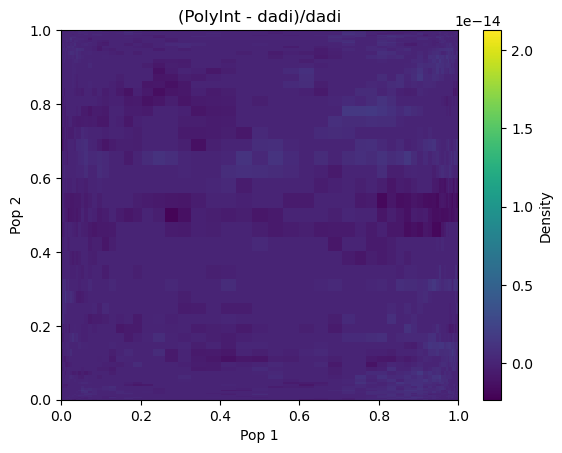

In [7]:
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx, gamma=-2)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

autoflag = PolyInt.PloidyType.AUTO
T = .15
gamma1 = -2
gamma2 = 10
h1 = 0.5
h2 = 0.5
m12 = 0.01
m21 = 0.1
m12_auto = m12/2
m21_auto = m21/2
sel_1 = {'gamma': gamma1}
sel_2 = {'gamma': gamma2}
nu1 = 1.5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu1_func_auto = lambda t: np.exp(np.log(nu1)*t/(2*T))
nu2 = 3.0
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
nu2_func_auto = lambda t: np.exp(np.log(nu2)*t/(2*T))

phi_poly = PolyInt.two_pops(phi.copy(), xx, T=2*T, ploidyflag1=autoflag, ploidyflag2=autoflag, sel_dict1=sel_1,
                           sel_dict2=sel_2, nu1=nu1_func_auto, nu2=nu2_func_auto, m12=m12_auto, m21=m21_auto, theta0=0.5)

phi_dadi = dadi.Integration.two_pops(phi.copy(), xx, T=T, gamma1=gamma1, gamma2=gamma2, h1=h1, h2=h2, 
                                    m12=m12, m21=m21, nu1=nu1_func, nu2=nu2_func, theta0=1)

mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

compare_phis(phi_poly, phi_dadi, edges, 'Pop 1', 'Pop 2')

## Third, we want to test allotetraploids without selection

In [6]:
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

alloaflag = PolyInt.PloidyType.ALLOa
allobflag = PolyInt.PloidyType.ALLOb
T = 20
gamma1 = 0
gamma2 = 0
h1 = 0.5
h2 = 0.5
m12 = 5
m21 = 5
sel_1 = {'gamma': gamma1}
sel_2 = {'gamma': gamma2}
nu1 = 1.5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 1.5
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)

phi_poly = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=alloaflag, ploidyflag2=allobflag, sel_dict1=sel_1,
                           sel_dict2=sel_1, nu1=nu1_func, nu2=nu2_func, m12=m12, m21=m21, theta0=1)

# phi_dadi = dadi.Integration.two_pops(phi.copy(), xx, T=T, gamma1=gamma1, gamma2=gamma2, h1=h1, h2=h2, 
#                                     m12=m12, m21=m21, nu1=nu1_func, nu2=nu2_func, theta0=1)

# mid = 0.5 * (xx[1:] + xx[:-1])
# first = xx[0] - (mid[0] - xx[0])
# last = xx[-1] + (xx[-1] - mid[-1])
# edges = np.concatenate([[first], mid, [last]])

# compare_phis(phi_poly, phi_dadi, edges, 'Pop 1', 'Pop 2')

## Fourth, we want to test all autohexaploids with 1/3 migration, tripled time, equal selection, and no mutation

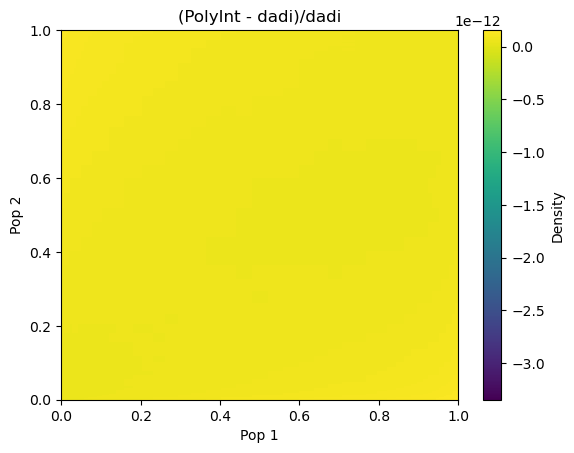

In [14]:
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx, gamma=-2)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

hexflag = PolyInt.PloidyType.AUTOHEX
T = .15
gamma1 = -2
gamma2 = 10
h1 = 0.5
h2 = 0.5
m12 = 0.01
m21 = 0.1
m12_hex = m12/3
m21_hex = m21/3
sel_1 = {'gamma': gamma1}
sel_2 = {'gamma': gamma2}
nu1 = 1.5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu1_func_auto = lambda t: np.exp(np.log(nu1)*t/(3*T))
nu2 = 3.0
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
nu2_func_auto = lambda t: np.exp(np.log(nu2)*t/(3*T))

phi_poly = PolyInt.two_pops(phi.copy(), xx, T=3*T, ploidyflag1=hexflag, ploidyflag2=hexflag, sel_dict1=sel_1,
                           sel_dict2=sel_2, nu1=nu1_func_auto, nu2=nu2_func_auto, m12=m12_hex, m21=m21_hex, theta0=0)

phi_dadi = dadi.Integration.two_pops(phi.copy(), xx, T=T, gamma1=gamma1, gamma2=gamma2, h1=h1, h2=h2, 
                                    m12=m12, m21=m21, nu1=nu1_func, nu2=nu2_func, theta0=0)

mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

compare_phis(phi_poly, phi_dadi, edges, 'Pop 1', 'Pop 2')

### Finally, I include the code for 4+2 hexaploids here, but we cannot test this against dadi
This is used to validate the CPU and GPU versions of the code.

In [ ]:
import numpy as np
import dadi 
from matplotlib import pyplot as plt
import dadi.Polyploidy.Integration as PolyInt

xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

hextetraflag = PolyInt.PloidyType.HEX_tetra
hexdipflag = PolyInt.PloidyType.HEX_dip
T = .15
gamma1 = 0
gamma2 = 0
h1 = 0.5
h2 = 0.5
m12 = 0.1
m21 = 0.1
sel_1 = {'gamma': gamma1}
sel_2 = {'gamma': gamma2}
nu1 = 1.5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 1.5
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)

phi_poly = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=hextetraflag, ploidyflag2=hexdipflag, sel_dict1=sel_1,
                           sel_dict2=sel_1, nu1=nu1_func, nu2=nu2_func, m12=m12, m21=m21, theta0=1)

# Testing against WF simulations

## Then, we can test against the WF model for auto-dip

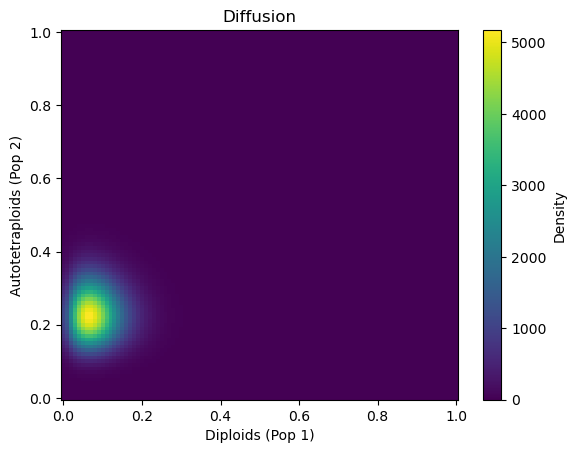

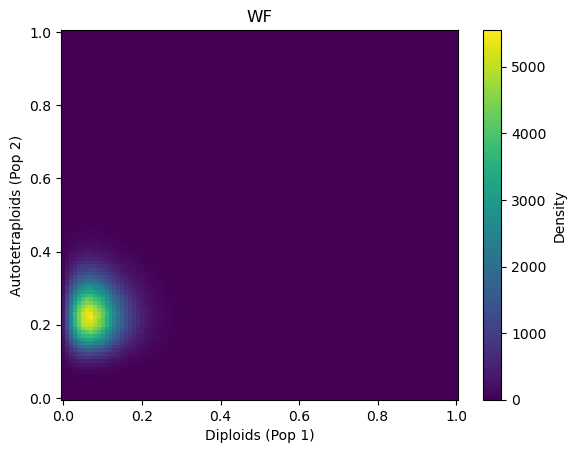

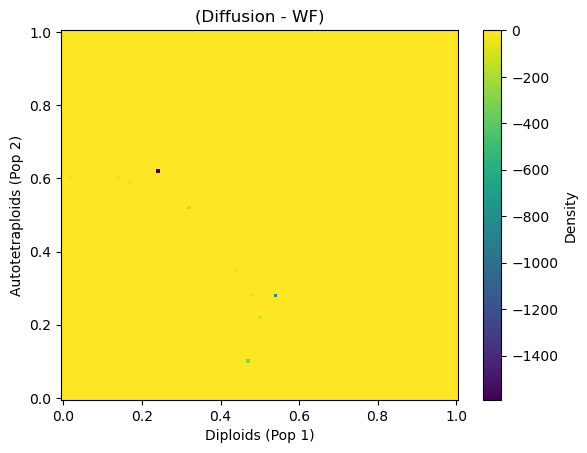

In [23]:
pts=101
#xx = dadi.Numerics.default_grid(pts, crwd=3)
#print(xx[1] - xx[0])
xx = np.linspace(0, 1, pts)
phi = np.zeros([xx.size, xx.size])

i, j = 50, 50

dipflag = PolyInt.PloidyType.DIPLOID
autoflag = PolyInt.PloidyType.AUTO
T = .06
gam1 = -40
gam2 = -40
h1 = 0.5
h2 = 0.5
m12 = 0
m21 = 0
sel_dip = {'gamma': gam1}
sel_auto = {'gamma': gam2} # this will return additive dominance
sel_dip_vec = dipflag.pack_sel_params(sel_dip)
sel_auto_vec = autoflag.pack_sel_params(sel_auto)
nu1 = 1
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 1
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
N = 5000
replicates = 1000000

phi[i,j] = replicates

# integrate the diffusion model
phi = PolyInt.two_pops(phi, xx, T, nu1, nu2, m12, m21, sel_dip, sel_auto, dipflag, autoflag, theta0=0)

#phi /= np.trapezoid(np.trapezoid(phi, xx), xx)

# plot the result from the diffusion model
mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

plt.pcolormesh(edges, edges, phi.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Diploids (Pop 1)')
plt.ylabel('Autotetraploids (Pop 2)')
plt.title('Diffusion')
plt.show()


q1 =np.full(replicates, xx[i])
q2 = np.full(replicates, xx[j])

allele_freqs = WF.auto_dip_migration_WF(N, T, M_12=m12, M_21=m21, sel1=sel_dip_vec, sel2=sel_auto_vec, 
                                        nu1=nu1, nu2=nu2,
                                        init_q1=q1, init_q2=q2, replicates=replicates)
# separate diploid and auto frequencies
auto_freqs = allele_freqs[0, :]
dip_freqs = allele_freqs[1, :]

hist, xedges, yedges = np.histogram2d(x=dip_freqs.flatten(), y=auto_freqs.flatten(), bins=[edges, edges])

# remove lost or fixed alleles
hist[0, 0] = 0
hist[-1, -1] = 0

# plt.imshow(hist.T, cmap='viridis', origin='lower', extent=[0, 1, 0, 1], aspect='auto')
# plt.colorbar(label='Density')
# plt.xlabel('Diploids (Pop 1)')
# plt.ylabel('Autotetraploids (Pop 2)')
# plt.title('WF')
# plt.show()

plt.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Diploids (Pop 1)')
plt.ylabel('Autotetraploids (Pop 2)')
plt.title('WF')
plt.show()

plt.pcolormesh(edges, edges, (phi.T - hist.T)/phi.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Diploids (Pop 1)')
plt.ylabel('Autotetraploids (Pop 2)')
plt.title('(Diffusion - WF)')
plt.show()


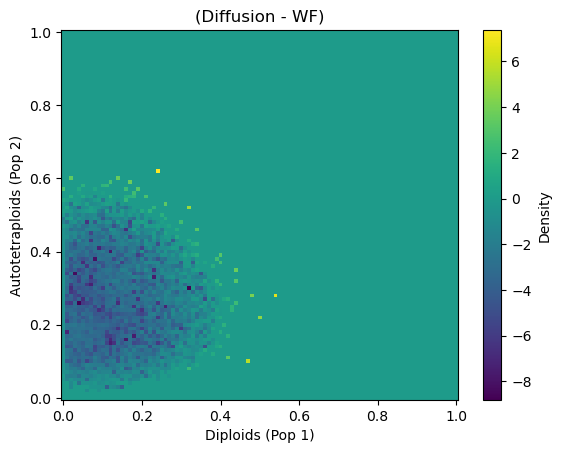

In [25]:
plt.pcolormesh(edges, edges, np.log(np.abs((phi.T - hist.T))/phi.T), cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Diploids (Pop 1)')
plt.ylabel('Autotetraploids (Pop 2)')
plt.title('(Diffusion - WF)')
plt.show()

### Compare the marginal distributions

WF MODEL
Autotetraploid Results Summary
Retained density for autotetraploids is: 1.0
Mean final allele frequency for autotetraploids: 0.42708091
Variance of final allele frequency for autotetraploids: 0.011688197171071899


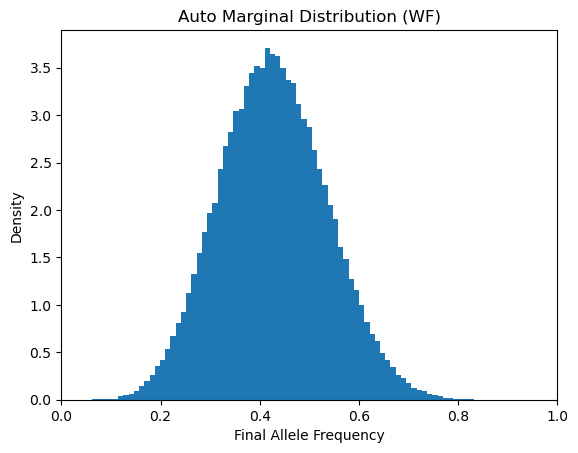

Diploid Results Summary
Retained density for diploids is: 0.99994
Mean final allele frequency for diploids: 0.3604810088605316
Variance of final allele frequency for diploids: 0.021000146258133748


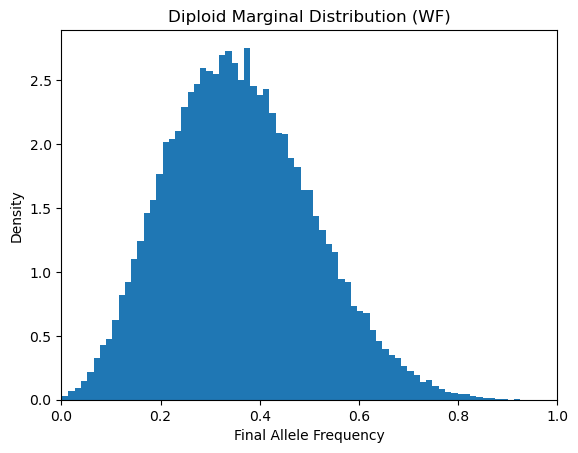

Autotetraploid Results Summary
Mean: 0.4273906513852063
Variance: 0.011796345727878577


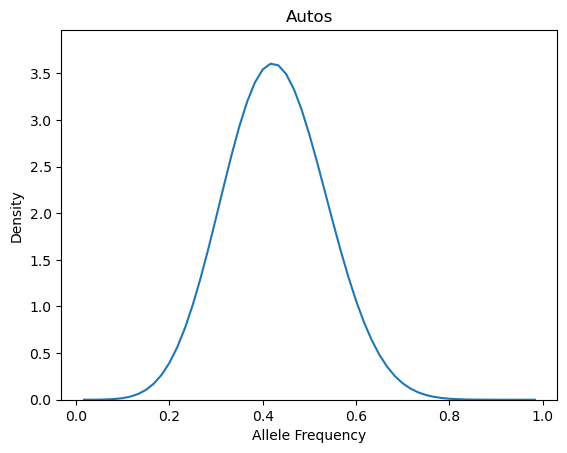

Diploid Results Summary
Mean: 0.36127302308585696
Variance: 0.020931636191214575


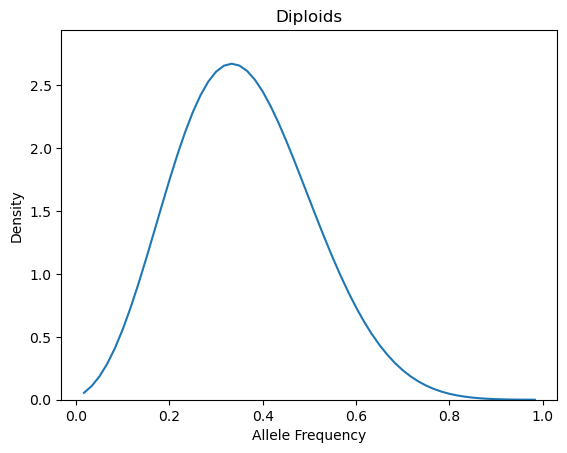

In [3]:
# mask to remove fixed and lost trajectories
auto_polymorphic = WF.mask(auto_freqs)
dip_polymorphic = WF.mask(dip_freqs)

# COMPARE MARGINALIZED PHI

# WF MODEL
# Compute and print retained density, means, and variances of each model
# Autos first
print("WF MODEL")
print("Autotetraploid Results Summary")
print(f"Retained density for autotetraploids is: {auto_polymorphic.size/auto_freqs.size}")
print(f"Mean final allele frequency for autotetraploids: {np.mean(auto_polymorphic)}")
print(f"Variance of final allele frequency for autotetraploids: {np.var(auto_polymorphic)}")
# Plot histogram of final allele frequencies
plt.hist(auto_polymorphic, bins = 75, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Auto Marginal Distribution (WF)')
plt.xlim(0, 1)
plt.show()

# And diploids too
print("Diploid Results Summary")
print(f"Retained density for diploids is: {dip_polymorphic.size/dip_freqs.size}")
print(f"Mean final allele frequency for diploids: {np.mean(dip_polymorphic)}")
print(f"Variance of final allele frequency for diploids: {np.var(dip_polymorphic)}")
# Plot histogram of final allele frequencies
plt.hist(dip_polymorphic, bins = 75, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Diploid Marginal Distribution (WF)')
plt.xlim(0, 1)
plt.show()

# DIFFUSION MODEL
# for comparisons to the above, we will want to marginalize phi
# marginalize
auto_phi = np.sum(phi, axis=0)
# down project the marginalized phi to the polymorphic portion
auto_phi = auto_phi[1:-1]
# create compatible grid for polymorphic phi
xx = xx[1:-1]
print("Autotetraploid Results Summary")
WF.summarize_phi(auto_phi, xx, 'Autos')

# same as above, but for diploids
dip_phi = np.sum(phi, axis=1)
dip_phi = dip_phi[1:-1]

print("Diploid Results Summary")
WF.summarize_phi(dip_phi, xx, 'Diploids')



## Then, we can test against the WF model for allotetraploids

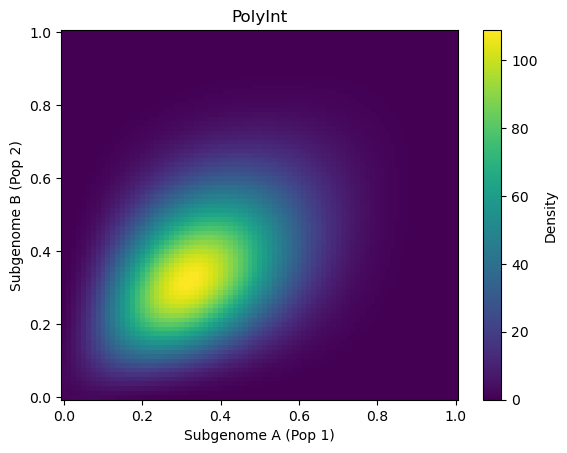

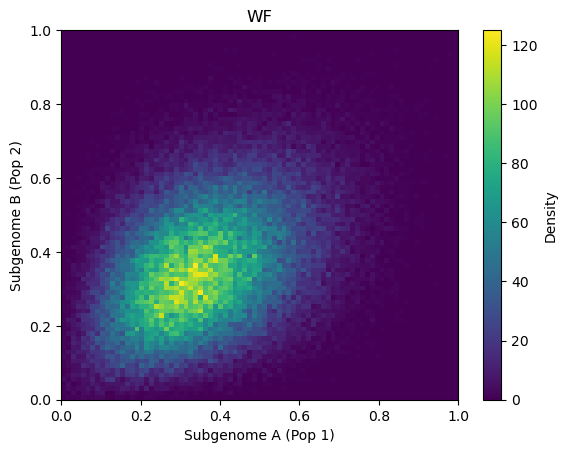

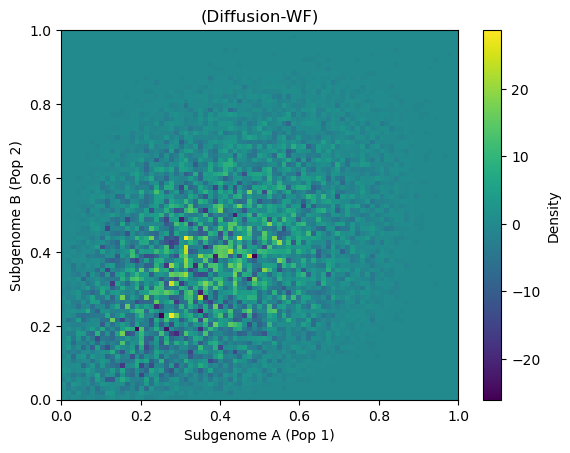

In [5]:
pts=81
replicates = 100000
#xx = dadi.Numerics.default_grid(pts)
xx = np.linspace(0, 1, pts)
phi = np.zeros([xx.size, xx.size])

i, j = 40, 40

phi[i,j] = 100000

alloaflag = PolyInt.PloidyType.ALLOa
allobflag = PolyInt.PloidyType.ALLOb
T = .15
g01 = -2
g02 = -4
g10 = -2
g11 = -4
g12 = -6
g20 = -4
g21 = -6
g22 = -8
e12 = m12 = m21 = 3
sel_allo = {'gamma': g22}
nu1 = 1
nu2 = 1
N = 1000

# integrate the diffusion model
phi = PolyInt.two_pops(phi, xx, T, nu1, nu2, m12, m21, sel_allo, sel_allo, alloaflag, allobflag, theta0=0)

# plot the result from the diffusion model
mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

plt.pcolormesh(edges, edges, phi.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Subgenome A (Pop 1)')
plt.ylabel('Subgenome B (Pop 2)')
plt.title('PolyInt')
plt.show()

allele_freqs = WF.allo_allelic_WF(N, T, e12, g01, g02, g10, g11, g12, g20, g21, g22,
                                  init_qa=np.full(replicates,xx[i]), init_qb=np.full(replicates,xx[j]), replicates=replicates)

# separate diploid and auto frequencies
alloa_freqs = allele_freqs[0, :]
allob_freqs = allele_freqs[1, :]

alloa_edges = np.linspace(0, 1, pts+1)
allob_edges = np.linspace(0, 1, pts+1)
hist, xedges, yedges = np.histogram2d(x=alloa_freqs.flatten(), y=allob_freqs.flatten(), bins=[alloa_edges, allob_edges])

# remove lost or fixed alleles
hist[0, 0] = 0
hist[-1, -1] = 0

# Transpose due to row/column orientation
plt.imshow(hist.T, cmap='viridis', origin='lower', extent=[0, 1, 0, 1], aspect='auto')
plt.colorbar(label='Density')
plt.xlabel('Subgenome A (Pop 1)')
plt.ylabel('Subgenome B (Pop 2)')
plt.title('WF')
plt.show()

plt.imshow((phi.T - hist.T), cmap='viridis', origin='lower', extent=[0, 1, 0, 1], aspect='auto')
plt.colorbar(label='Density')
plt.xlabel('Subgenome A (Pop 1)')
plt.ylabel('Subgenome B (Pop 2)')
plt.title('(Diffusion-WF)')
plt.show()

WF MODEL
Allo Subgenome A Results Summary
Retained density for subgenome A is: 0.99997
Mean final allele frequency for subgenome A: 0.36174903747112414
Variance of final allele frequency for subgenome A: 0.022834550188704235


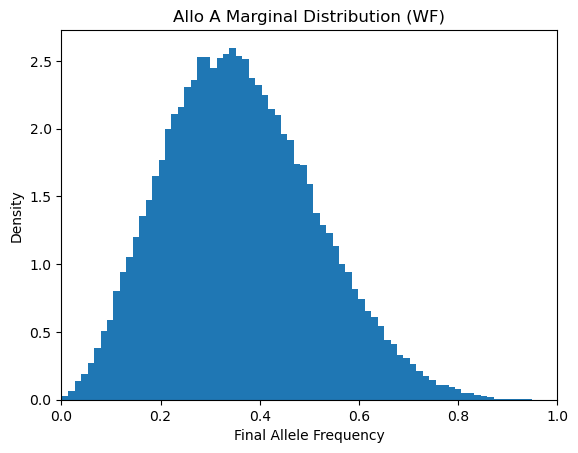

Allo Subgenome B Results Summary
Retained density for subgenome B is: 0.99999
Mean final allele frequency for subgenome B: 0.36164524645246454
Variance of final allele frequency for subgenome B: 0.022873733773516744


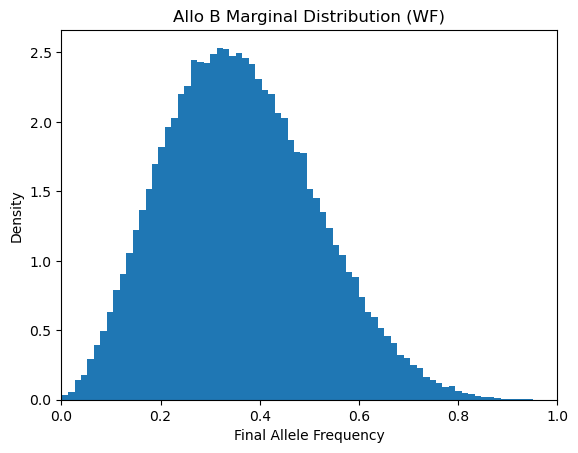

Allo Subgenome A Results Summary
Mean: 0.36235997354566346
Variance: 0.02278937519182725


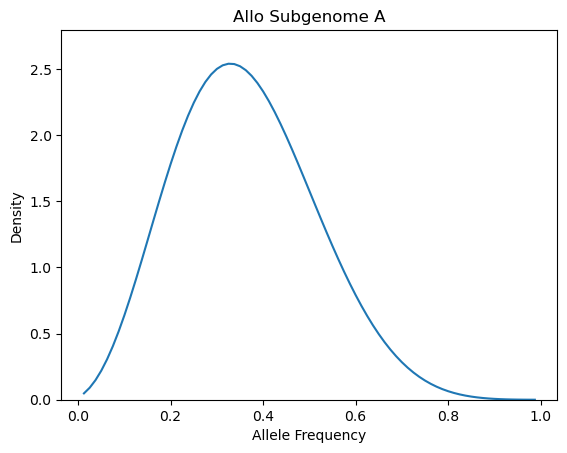

Allo Subgenome B Results Summary
Mean: 0.3622767033023122
Variance: 0.022792105972820553


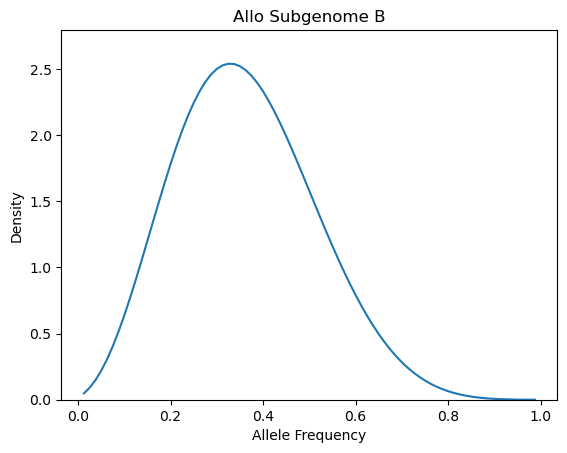

In [6]:
# mask to remove fixed and lost trajectories
alloa_polymorphic = WF.mask(alloa_freqs)
allob_polymorphic = WF.mask(allob_freqs)

# COMPARE MARGINALIZED PHI

# WF MODEL
# Compute and print retained density, means, and variances of each model
# Autos first
print("WF MODEL")
print("Allo Subgenome A Results Summary")
print(f"Retained density for subgenome A is: {alloa_polymorphic.size/alloa_freqs.size}")
print(f"Mean final allele frequency for subgenome A: {np.mean(alloa_polymorphic)}")
print(f"Variance of final allele frequency for subgenome A: {np.var(alloa_polymorphic)}")
# Plot histogram of final allele frequencies
plt.hist(alloa_polymorphic, bins = 75, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Allo A Marginal Distribution (WF)')
plt.xlim(0, 1)
plt.show()

# And diploids too
print("Allo Subgenome B Results Summary")
print(f"Retained density for subgenome B is: {allob_polymorphic.size/allob_freqs.size}")
print(f"Mean final allele frequency for subgenome B: {np.mean(allob_polymorphic)}")
print(f"Variance of final allele frequency for subgenome B: {np.var(allob_polymorphic)}")
# Plot histogram of final allele frequencies
plt.hist(allob_polymorphic, bins = 75, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Allo B Marginal Distribution (WF)')
plt.xlim(0, 1)
plt.show()

# DIFFUSION MODEL
# for comparisons to the above, we will want to marginalize phi
# marginalize
alloa_phi = np.sum(phi, axis=1)
# down project the marginalized phi to the polymorphic portion
alloa_phi = alloa_phi[1:-1]
# create compatible grid for polymorphic phi
xx = xx[1:-1]
print("Allo Subgenome A Results Summary")
WF.summarize_phi(alloa_phi, xx, 'Allo Subgenome A')

# same as above, but for diploids
allob_phi = np.sum(phi, axis=0)
allob_phi = allob_phi[1:-1]

print("Allo Subgenome B Results Summary")
WF.summarize_phi(allob_phi, xx, 'Allo Subgenome B')



### Now, let's test if switching the order of the allo subgenomes impacts the integration

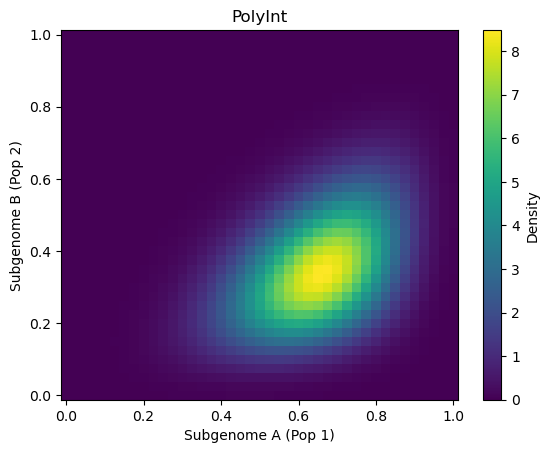

In [ ]:
pts=41
#xx = dadi.Numerics.default_grid(pts)
xx = np.linspace(0, 1, pts)
phi = np.zeros([xx.size, xx.size])

i = int((pts-1)/2 - 7)
j = int((pts-1)/2 + 7)

# note that we also switch where we place the initial mass by swapping i and j
phi[j,i] = 1

alloaflag = PolyInt.PloidyType.ALLOa
allobflag = PolyInt.PloidyType.ALLOb
T = .1
g01 = -12
g02 = -24
g10 = 2
g11 = 0
g12 = -12
g20 = 4
g21 = 2
g22 = 0
e12 = m12 = m21 = 0
sel_allo = {'gamma01': g01, 'gamma02': g02, 'gamma10': g10, 'gamma11': g11, 'gamma12': g12, 'gamma20': g20, 'gamma21': g21, 'gamma22': g22}
nu1 = 1
nu2 = 1
N = 1000

# integrate the diffusion model
phi = PolyInt.two_pops(phi, xx, T, nu1, nu2, m12, m21, sel_allo, sel_allo, allobflag, alloaflag, theta0=0)

# let's try calculating retained mass
retained = np.trapezoid(
    np.trapezoid(phi, xx, axis=0),
    xx, axis=0)

# normalize to a probability distribution, kind of
phi /= retained

# plot the result from the diffusion model
mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

# skip the transpose because I swapped the order in which I passed the subgenomes to the integrator
plt.pcolormesh(edges, edges, phi, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Subgenome A (Pop 1)')
plt.ylabel('Subgenome B (Pop 2)')
plt.title('PolyInt')
plt.show()

allele_freqs = WF.allo_allelic_WF(N, T, e12, g01, g02, g10, g11, g12, g20, g21, g22,
                                  init_qa=np.full(1000000,xx[i]), init_qb=np.full(1000000,xx[j]), replicates=1000000)

# separate diploid and auto frequencies
alloa_freqs = allele_freqs[0, :]
allob_freqs = allele_freqs[1, :]

alloa_edges = np.linspace(0, 1, pts)
allob_edges = np.linspace(0, 1, pts)
hist, xedges, yedges = np.histogram2d(x=alloa_freqs.flatten(), y=allob_freqs.flatten(), bins=[alloa_edges, allob_edges])

# remove lost or fixed alleles
hist[0, 0] = 0
hist[-1, -1] = 0

# normalize to a probability density
hist_density = hist / hist.sum()

# Transpose due to row/column orientation
plt.imshow(hist_density.T, cmap='viridis', origin='lower', extent=[0, 1, 0, 1], aspect='auto')
plt.colorbar(label='Density')
plt.xlabel('Subgenome A (Pop 1)')
plt.ylabel('Subgenome B (Pop 2)')
plt.title('WF')
plt.show()

## Test Hexaploid (4+2) model

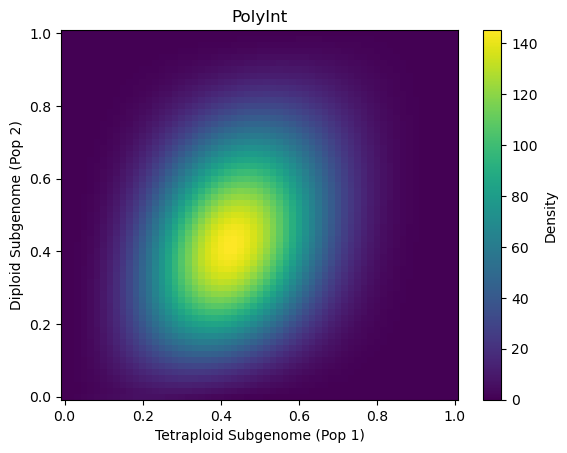

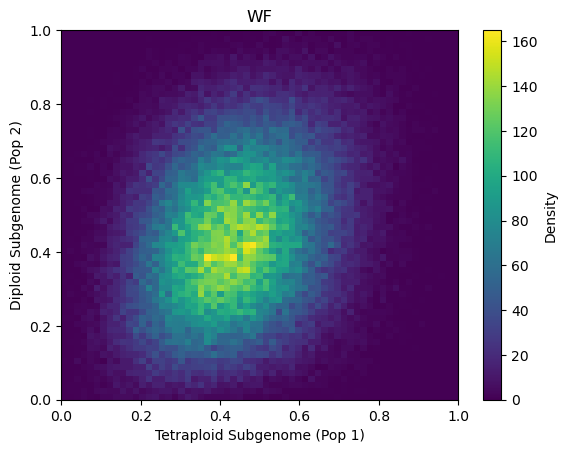

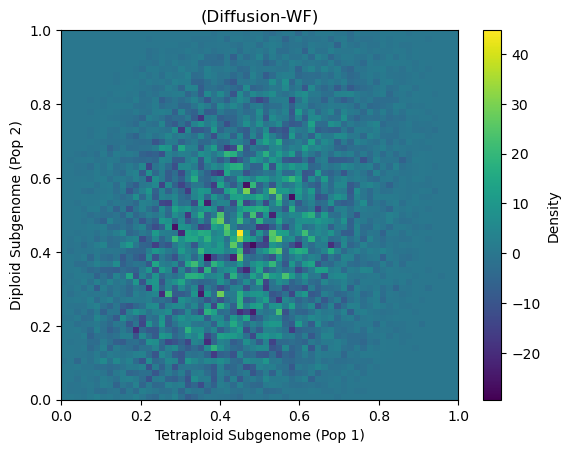

In [12]:
pts=61
replicates = 100000
#xx = dadi.Numerics.default_grid(pts)
xx = np.linspace(0, 1, pts)
phi = np.zeros([xx.size, xx.size])

i, j = 30, 30

phi[i,j] = replicates

hex_tetraflag = PolyInt.PloidyType.HEX_tetra
hex_dipflag = PolyInt.PloidyType.HEX_dip
T = .15
gamma = -5
e12 = m12 = m21 = 3
sel_dict = {'gamma': gamma}
sel_vec = hex_tetraflag.pack_sel_params(sel_dict)
nu1 = .5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = .5
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
N = 1000

# integrate the diffusion model
phi = PolyInt.two_pops(phi, xx, T, nu1_func, nu2_func, m12, m21, sel_dict, sel_dict, hex_tetraflag, hex_dipflag, theta0=0)

# plot the result from the diffusion model
mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

plt.pcolormesh(edges, edges, phi.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Tetraploid Subgenome (Pop 1)')
plt.ylabel('Diploid Subgenome (Pop 2)')
plt.title('PolyInt')
plt.show()

allele_freqs = WF.hex_4_2_WF(N, T, e12, s=sel_vec, init_q4=np.full(replicates,xx[i]), 
                             init_q2=np.full(replicates,xx[j]), replicates=replicates, nu = nu1_func)

# separate diploid and auto frequencies
alloa_freqs = allele_freqs[0, :]
allob_freqs = allele_freqs[1, :]

alloa_edges = np.linspace(0, 1, pts+1)
allob_edges = np.linspace(0, 1, pts+1)
hist, xedges, yedges = np.histogram2d(x=alloa_freqs.flatten(), y=allob_freqs.flatten(), bins=[alloa_edges, allob_edges])

# remove lost or fixed alleles
hist[0, 0] = 0
hist[-1, -1] = 0

# Transpose due to row/column orientation
plt.imshow(hist.T, cmap='viridis', origin='lower', extent=[0, 1, 0, 1], aspect='auto')
plt.colorbar(label='Density')
plt.xlabel('Tetraploid Subgenome (Pop 1)')
plt.ylabel('Diploid Subgenome (Pop 2)')
plt.title('WF')
plt.show()

plt.imshow((phi.T - hist.T), cmap='viridis', origin='lower', extent=[0, 1, 0, 1], aspect='auto')
plt.colorbar(label='Density')
plt.xlabel('Tetraploid Subgenome (Pop 1)')
plt.ylabel('Diploid Subgenome (Pop 2)')
plt.title('(Diffusion-WF)')
plt.show()

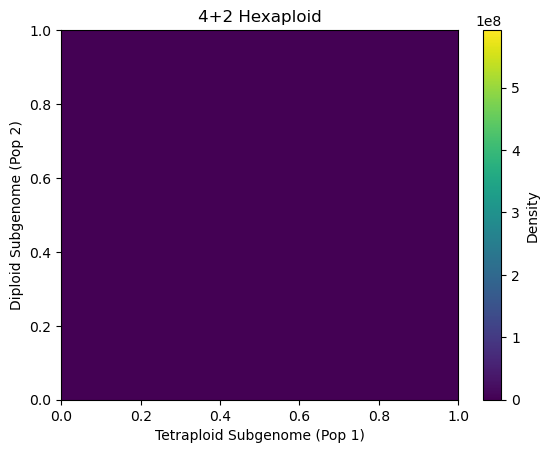

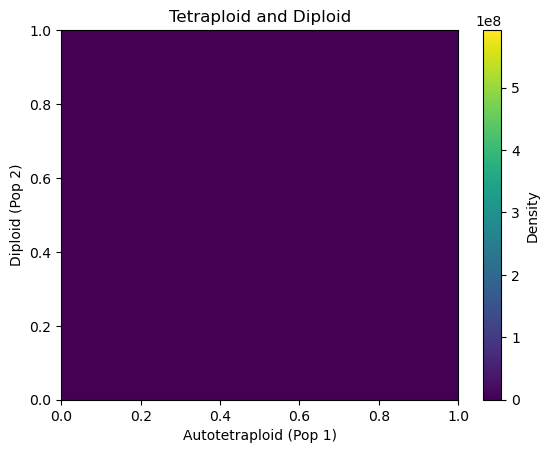

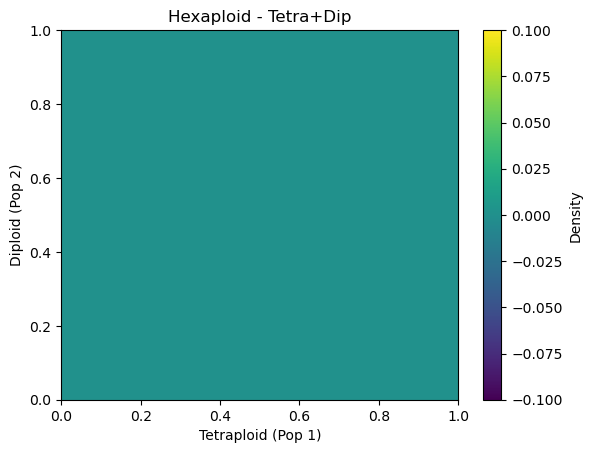

In [21]:
xx = dadi.Numerics.default_grid(pts=101)
phi = dadi.PhiManip.phi_1D(xx)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

# test 4+2 hexaploid against a diploid and autotetraploid without selection
hex_tetraflag = PolyInt.PloidyType.HEX_tetra
hex_dipflag = PolyInt.PloidyType.HEX_dip

autoflag = PolyInt.PloidyType.AUTO
dipflag = PolyInt.PloidyType.DIPLOID
T = 5
gamma = 0
e12 = m12 = m21 = 3
sel_dict = {'gamma': gamma}
nu1 = 1
nu2 = 1
N = 1000

# integrate the diffusion model
phi1 = PolyInt.two_pops(phi, xx, T, nu1, nu2, e12, e12, sel_dict, sel_dict, hex_tetraflag, hex_dipflag, theta0=1)

# plot the result from the diffusion model
mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

plt.pcolormesh(edges, edges, phi1.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Tetraploid Subgenome (Pop 1)')
plt.ylabel('Diploid Subgenome (Pop 2)')
plt.title('4+2 Hexaploid')
plt.show()

phi2 = PolyInt.two_pops(phi, xx, T, nu1, nu2, m12/2, m21, sel_dict, sel_dict, autoflag, dipflag, theta0=1)

plt.pcolormesh(edges, edges, phi2.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Autotetraploid (Pop 1)')
plt.ylabel('Diploid (Pop 2)')
plt.title('Tetraploid and Diploid')
plt.show()

plt.pcolormesh(edges, edges, phi2.T - phi1.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Tetraploid (Pop 1)')
plt.ylabel('Diploid (Pop 2)')
plt.title('Hexaploid - Tetra+Dip')
plt.show()

## 2 Diploid Populations WF vs. dadi vs. PolyInt

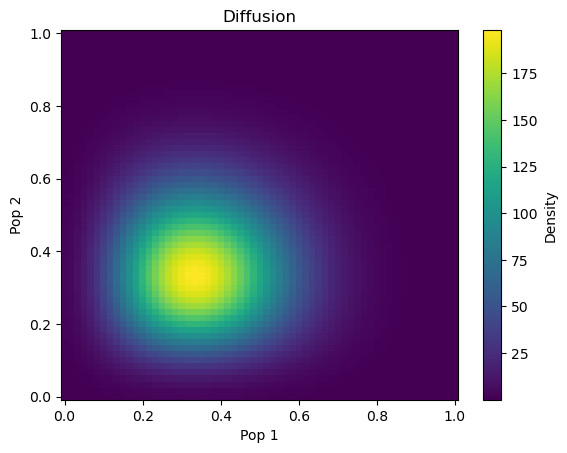

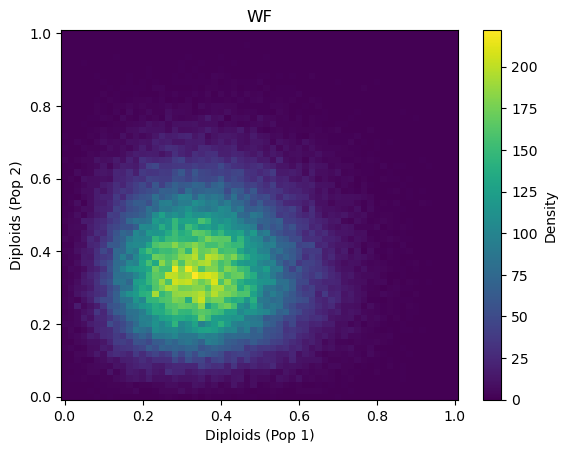

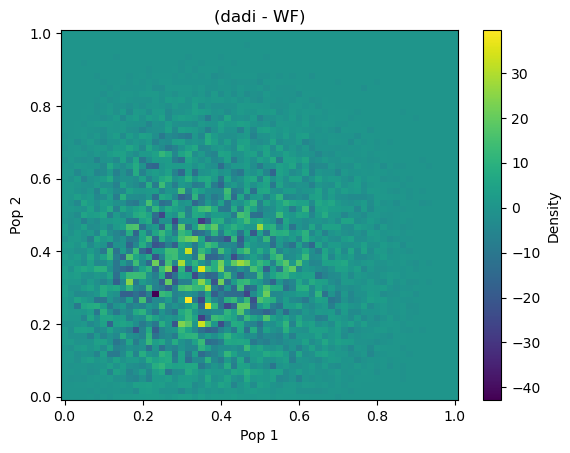

In [4]:
pts=61
#xx = dadi.Numerics.default_grid(pts, crwd=3)
xx = np.linspace(0, 1, pts)
phi = np.zeros([xx.size, xx.size])

i, j = 30, 30

dipflag = PolyInt.PloidyType.DIPLOID
T = .1
gam1 = -6
gam2 = -6
h1 = 0.5
h2 = 0.5
m12 = 0
m21 = 0
sel1 = {'gamma': gam1} # this will return additive dominance
sel2 = {'gamma': gam2} # this will return additive dominance
sel_vec1 = dipflag.pack_sel_params(sel1)
sel_vec2 = dipflag.pack_sel_params(sel2)
nu1 = 1
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 1
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
N = 1000
replicates = 100000
phi[i,j] = replicates

# integrate the diffusion model
phi = PolyInt.two_pops(phi, xx, T, nu1, nu2, m12, m21, sel1, sel2, dipflag, dipflag, theta0=0)

# plot the result from the diffusion model
mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

plt.pcolormesh(edges, edges, phi.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 2')
plt.title('Diffusion')
plt.show()

q1 =np.full(replicates, xx[i])
q2 = np.full(replicates, xx[j])

allele_freqs = WF.dip_dip_migration_WF(N, T, M_12=m12, M_21=m21, sel1=sel_vec1, sel2=sel_vec2, 
                                        nu1=nu1, nu2=nu2,
                                        init_q1=q1, init_q2=q2, replicates=replicates)
# separate diploid and auto frequencies
pop1_freqs = allele_freqs[0, :]
pop2_freqs = allele_freqs[1, :]

hist, xedges, yedges = np.histogram2d(x=pop1_freqs.flatten(), y=pop2_freqs.flatten(), bins=[edges, edges])

# remove lost or fixed alleles
hist[0, 0] = 0
hist[-1, -1] = 0


# plt.imshow(hist.T, cmap='viridis', origin='lower', extent=[0, 1, 0, 1], aspect='auto')
# plt.colorbar(label='Density')
# plt.xlabel('Pop 1')
# plt.ylabel('Pop 2')
# plt.title('WF')
# plt.show()

plt.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Diploids (Pop 1)')
plt.ylabel('Diploids (Pop 2)')
plt.title('WF')
plt.show()

plt.pcolormesh(edges, edges, (phi.T - hist.T), cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 2')
plt.title('(dadi - WF)')
plt.show()


WF MODEL
Pop1 Results Summary
Retained density is: 1.0
Mean final allele frequency: 0.375600825
Variance of final allele frequency: 0.017081549561819374


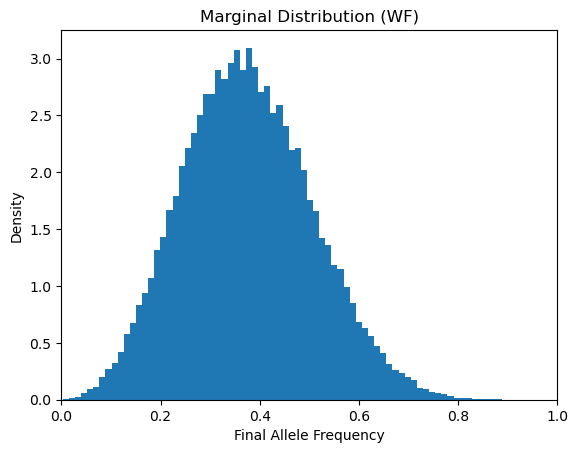

Pop2 Results Summary
Retained density is: 0.99998
Mean final allele frequency: 0.3759405788115763
Variance of final allele frequency: 0.016920438732967644


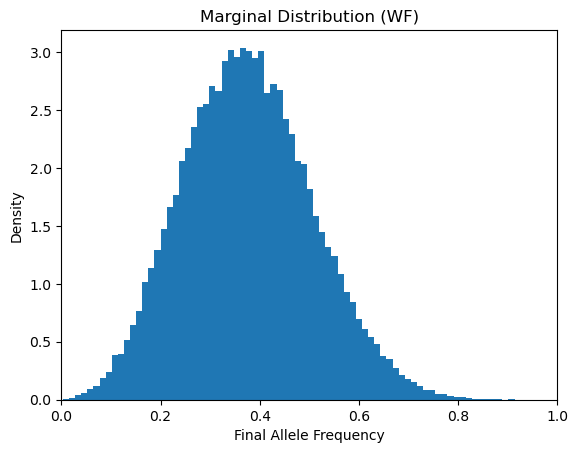

Autotetraploid Results Summary
Mean: 0.360745273587315
Variance: 0.02072725473151385


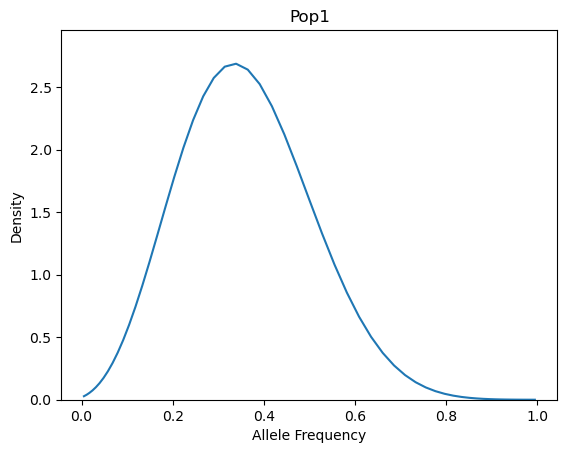

Diploid Results Summary
Mean: 0.3607369270108535
Variance: 0.020727084310992294


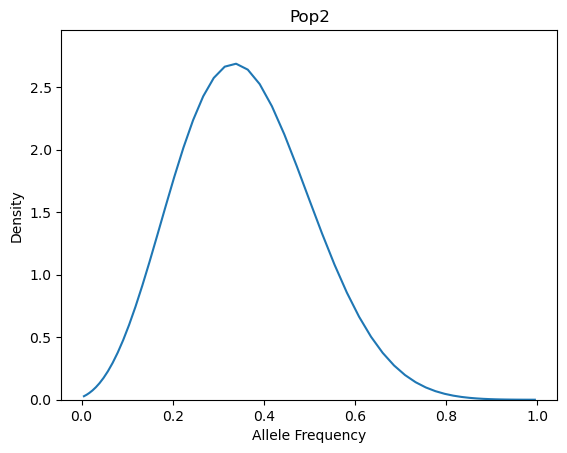

In [67]:
# mask to remove fixed and lost trajectories
pop1_polymorphic = WF.mask(pop1_freqs)
pop2_polymorphic = WF.mask(pop2_freqs)

# COMPARE MARGINALIZED PHI

# WF MODEL
# Compute and print retained density, means, and variances of each model
# Autos first
print("WF MODEL")
print("Pop1 Results Summary")
print(f"Retained density is: {pop1_polymorphic.size/pop1_freqs.size}")
print(f"Mean final allele frequency: {np.mean(pop1_polymorphic)}")
print(f"Variance of final allele frequency: {np.var(pop1_polymorphic)}")
# Plot histogram of final allele frequencies
plt.hist(pop1_polymorphic, bins = 75, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Marginal Distribution (WF)')
plt.xlim(0, 1)
plt.show()

# And diploids too
print("Pop2 Results Summary")
print(f"Retained density is: {pop2_polymorphic.size/pop2_freqs.size}")
print(f"Mean final allele frequency: {np.mean(pop2_polymorphic)}")
print(f"Variance of final allele frequency: {np.var(pop2_polymorphic)}")
# Plot histogram of final allele frequencies
plt.hist(pop2_polymorphic, bins = 75, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Marginal Distribution (WF)')
plt.xlim(0, 1)
plt.show()

# DIFFUSION MODEL
# for comparisons to the above, we will want to marginalize phi
# marginalize
pop1_phi = np.sum(phi, axis=1)
# down project the marginalized phi to the polymorphic portion
pop1_phi = pop1_phi[1:-1]
# create compatible grid for polymorphic phi
xx = xx[1:-1]
print("Autotetraploid Results Summary")
WF.summarize_phi(pop1_phi, xx, 'Pop1')

# same as above, but for diploids
pop2_phi = np.sum(phi, axis=0)
pop2_phi = pop2_phi[1:-1]

print("Diploid Results Summary")
WF.summarize_phi(pop2_phi, xx, 'Pop2')



## Test Auto-Auto

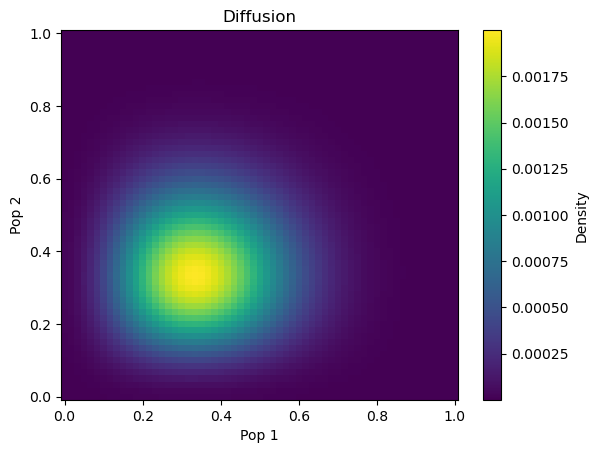

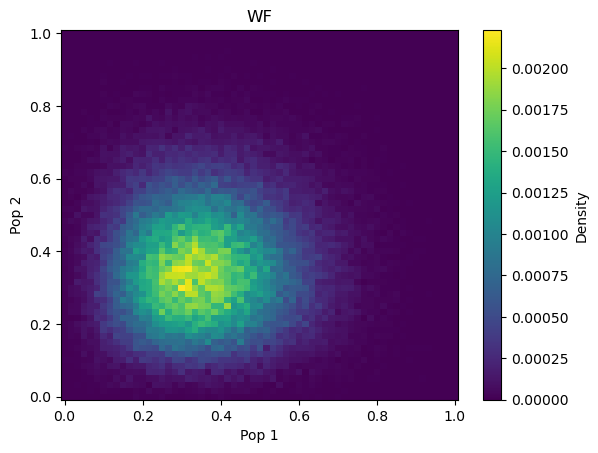

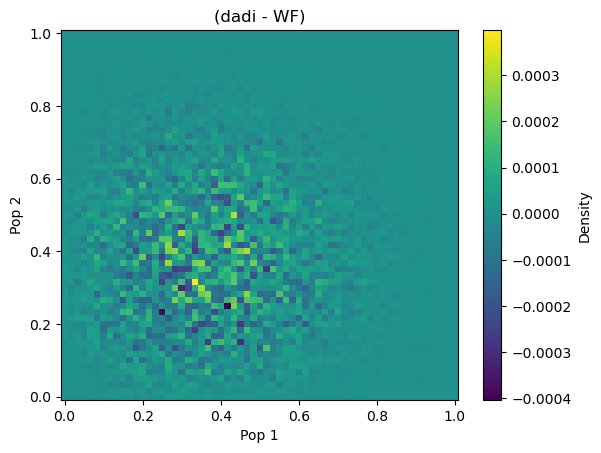

In [6]:
pts=61
#xx = dadi.Numerics.default_grid(pts, crwd=3)
xx = np.linspace(0, 1, pts)
phi = np.zeros([xx.size, xx.size])

i, j = 30, 30
phi[i,j] = 1

autoflag = PolyInt.PloidyType.AUTO
T = .2
gam1 = -6
gam2 = -6
h1 = 0.5
h2 = 0.5
m12 = .05
m21 = .05
sel1 = {'gamma': gam1} # this will return additive dominance
sel2 = {'gamma': gam2} # this will return additive dominance
sel_vec1 = autoflag.pack_sel_params(sel1)
sel_vec2 = autoflag.pack_sel_params(sel2)
nu1 = 1
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 1
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
N = 1000
replicates = 100000

# integrate the diffusion model
phi = PolyInt.two_pops(phi, xx, T, nu1, nu2, m12, m21, sel1, sel2, autoflag, autoflag, theta0=0)

phi /= np.sum(phi)

# plot the result from the diffusion model
mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

plt.pcolormesh(edges, edges, phi.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 2')
plt.title('Diffusion')
plt.show()

q1 =np.full(replicates, xx[i])
q2 = np.full(replicates, xx[j])

allele_freqs = WF.auto_auto_migration_WF(N, T, M_12=m12, M_21=m21, sel1=sel_vec1, sel2=sel_vec2, 
                                        nu1=nu1, nu2=nu2,
                                        init_q1=q1, init_q2=q2, replicates=replicates)
# separate diploid and auto frequencies
pop1_freqs = allele_freqs[0, :]
pop2_freqs = allele_freqs[1, :]

hist, xedges, yedges = np.histogram2d(x=pop1_freqs.flatten(), y=pop2_freqs.flatten(), bins=[edges, edges])

# remove lost or fixed alleles
# hist[0, 0] = 0
# hist[-1, -1] = 0

hist /= np.sum(hist)


# plt.imshow(hist.T, cmap='viridis', origin='lower', extent=[0, 1, 0, 1], aspect='auto')
# plt.colorbar(label='Density')
# plt.xlabel('Pop 1')
# plt.ylabel('Pop 2')
# plt.title('WF')
# plt.show()

plt.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 2')
plt.title('WF')
plt.show()

plt.pcolormesh(edges, edges, (phi.T - hist.T), cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 2')
plt.title('(dadi - WF)')
plt.show()


# Benchmarking

### Test Constant Parameters without Selection

(0.0, 0.059103364242764654)

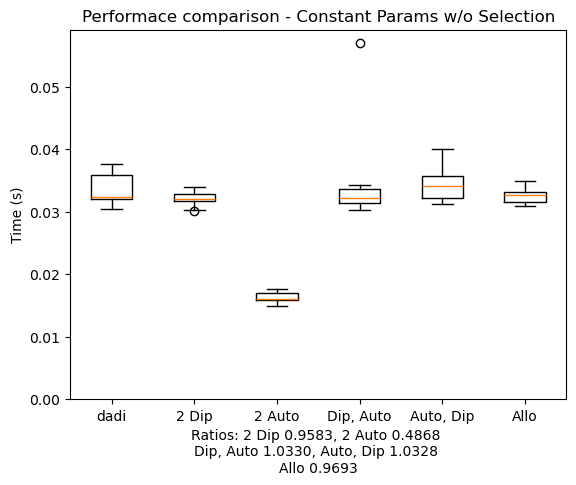

In [29]:
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx, gamma=-10, h=0.75)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

dipflag = PolyInt.PloidyType.DIPLOID
autoflag = PolyInt.PloidyType.AUTO
alloaflag = PolyInt.PloidyType.ALLOa
allobflag = PolyInt.PloidyType.ALLOb
T = 1
gamma1 = 0
gamma2 = 0
h1 = 0.75
h2 = 0.25
m12 = 0
m21 = 0
sel_dip1 = {'gamma': gamma1, 'h': h1}
sel_dip2 = {'gamma': gamma2, 'h': h2}
sel_auto1 = {'gamma1': gamma1/4, 'gamma2': gamma1/2, 'gamma3': 3*gamma1/4, 'gamma4': gamma1}
sel_auto2 = {'gamma1': gamma2/4, 'gamma2': gamma2/2, 'gamma3': 3*gamma2/4, 'gamma4': gamma2}
sel_allo = {'gamma01': gamma2/4, 'gamma02': gamma2/2, 'gamma10': gamma2/4, 'gamma11': gamma2/2, 'gamma12': 3*gamma2/4, 'gamma20': gamma2/2, 'gamma21': 3*gamma2/4, 'gamma22': gamma2}
nu1 = 1
nu2 = 1
iterations = 10

dadi_perf = np.empty(iterations)
poly_perf = np.empty(iterations)
auto_perf = np.empty(iterations)
dipauto_perf = np.empty(iterations)
autodip_perf = np.empty(iterations)
allo_perf = np.empty(iterations)
for i in range(iterations):
    start = time.perf_counter()
    phi = dadi.Integration.two_pops(phi.copy(), xx, T=T, theta0=1, gamma1=gamma1, gamma2=gamma2,h1=h1, h2=h2, 
                                    m12=m12, m21=m21, nu1=nu1, nu2=nu2)
    end = time.perf_counter()
    dadi_perf[i] = end - start
    
    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=dipflag, ploidyflag2=dipflag, sel_dict1=sel_dip1,
                           sel_dict2=sel_dip2, nu1=nu1, nu2=nu2, m12=m12, m21=m21)
    end = time.perf_counter()
    poly_perf[i] = end - start


    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=autoflag, ploidyflag2=autoflag, sel_dict1=sel_auto1,
                           sel_dict2=sel_auto2, nu1=nu1, nu2=nu2, m12=m12, m21=m21)                      
    end = time.perf_counter()
    auto_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=dipflag, ploidyflag2=autoflag, sel_dict1=sel_dip1,
                           sel_dict2=sel_auto2, nu1=nu1, nu2=nu2, m12=m12, m21=m21)                      
    end = time.perf_counter()
    dipauto_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=autoflag, ploidyflag2=dipflag, sel_dict1=sel_auto1,
                           sel_dict2=sel_dip2, nu1=nu1, nu2=nu2, m12=m12, m21=m21)                      
    end = time.perf_counter()
    autodip_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=alloaflag, ploidyflag2=allobflag, sel_dict1=sel_allo,
                           sel_dict2=sel_allo, nu1=nu1, nu2=nu2, m12=m12, m21=m12)                      
    end = time.perf_counter()
    allo_perf[i] = end - start


# Plot boxplot of performance
performance = [dadi_perf, poly_perf, auto_perf, dipauto_perf, autodip_perf, allo_perf]

ratio_dip = np.mean(poly_perf)/np.mean(dadi_perf)
ratio_auto = np.mean(auto_perf)/np.mean(dadi_perf)
ratio_allo = np.mean(allo_perf)/np.mean(dadi_perf)
ratio_dipauto = np.mean(dipauto_perf)/np.mean(dadi_perf)
ratio_autodip = np.mean(autodip_perf)/np.mean(dadi_perf)

plt.boxplot(performance, tick_labels=['dadi', '2 Dip', '2 Auto', 'Dip, Auto', 'Auto, Dip', 'Allo'])
plt.title("Performace comparison - Constant Params w/o Selection")
plt.ylabel("Time (s)")
plt.xlabel(f"Ratios: 2 Dip {ratio_dip:.4f}, 2 Auto {ratio_auto:.4f} \n"
           f"Dip, Auto {ratio_dipauto:.4f}, Auto, Dip {ratio_autodip:.4f} \n"
           f"Allo {ratio_allo:.4f}")
plt.ylim(ymin=0)

### Test Constant Parameters with Selection

(0.0, 0.06540787846024614)

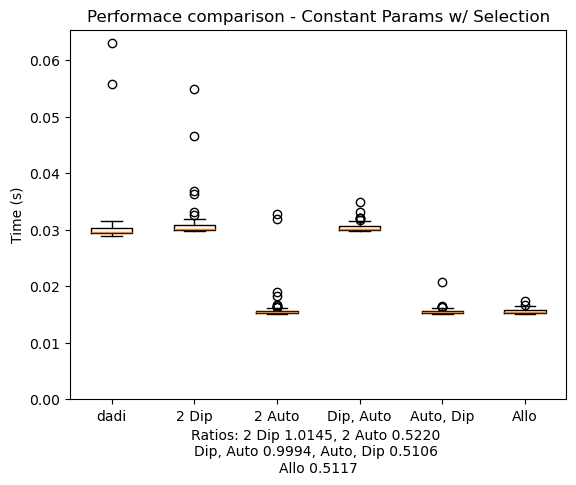

In [3]:
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx, gamma=-10, h=0.75)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

dipflag = PolyInt.PloidyType.DIPLOID
autoflag = PolyInt.PloidyType.AUTO
alloaflag = PolyInt.PloidyType.ALLOa
allobflag = PolyInt.PloidyType.ALLOb
T = .1
gamma1 = -10
gamma2 = -2
h1 = 0.75
h2 = 0.25
m12 = .01
m21 = 0.1
sel_dip1 = {'gamma': gamma1, 'h': h1}
sel_dip2 = {'gamma': gamma2, 'h': h2}
sel_auto1 = {'gamma1': gamma1/4, 'gamma2': gamma1/2, 'gamma3': 3*gamma1/4, 'gamma4': gamma1}
sel_auto2 = {'gamma1': gamma2/4, 'gamma2': gamma2/2, 'gamma3': 3*gamma2/4, 'gamma4': gamma2}
sel_allo = {'gamma01': gamma1/4, 'gamma02': gamma1/2, 'gamma10': gamma1/4, 'gamma11': gamma1/2, 'gamma12': 3*gamma1/4, 'gamma20': gamma1/2, 'gamma21': 3*gamma1/4, 'gamma22': gamma1}
nu1 = 1.5
nu2 = 3.0
iterations = 100

dadi_perf = np.empty(iterations)
poly_perf = np.empty(iterations)
auto_perf = np.empty(iterations)
dipauto_perf = np.empty(iterations)
autodip_perf = np.empty(iterations)
allo_perf = np.empty(iterations)
for i in range(iterations):
    start = time.perf_counter()
    phi = dadi.Integration.two_pops(phi.copy(), xx, T=T, theta0=1, gamma1=gamma1, gamma2=gamma2,h1=h1, h2=h2, 
                                    m12=m12, m21=m21, nu1=nu1, nu2=nu2)
    end = time.perf_counter()
    dadi_perf[i] = end - start
    
    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=dipflag, ploidyflag2=dipflag, sel_dict1=sel_dip1,
                           sel_dict2=sel_dip2, nu1=nu1, nu2=nu2, m12=m12, m21=m21)
    end = time.perf_counter()
    poly_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=autoflag, ploidyflag2=autoflag, sel_dict1=sel_auto1,
                           sel_dict2=sel_auto2, nu1=nu1, nu2=nu2, m12=m12, m21=m21)                      
    end = time.perf_counter()
    auto_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=dipflag, ploidyflag2=autoflag, sel_dict1=sel_dip1,
                           sel_dict2=sel_auto2, nu1=nu1, nu2=nu2, m12=m12, m21=m21)                      
    end = time.perf_counter()
    dipauto_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=autoflag, ploidyflag2=dipflag, sel_dict1=sel_auto1,
                           sel_dict2=sel_dip2, nu1=nu1, nu2=nu2, m12=m12, m21=m21)                      
    end = time.perf_counter()
    autodip_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=alloaflag, ploidyflag2=allobflag, sel_dict1=sel_allo,
                           sel_dict2=sel_allo, nu1=nu1, nu2=nu1, m12=m12, m21=m12)                      
    end = time.perf_counter()
    allo_perf[i] = end - start


# Plot boxplot of performance
performance = [dadi_perf, poly_perf, auto_perf, dipauto_perf, autodip_perf, allo_perf]

ratio_dip = np.mean(poly_perf)/np.mean(dadi_perf)
ratio_auto = np.mean(auto_perf)/np.mean(dadi_perf)
ratio_allo = np.mean(allo_perf)/np.mean(dadi_perf)
ratio_dipauto = np.mean(dipauto_perf)/np.mean(dadi_perf)
ratio_autodip = np.mean(autodip_perf)/np.mean(dadi_perf)

plt.boxplot(performance, tick_labels=['dadi', '2 Dip', '2 Auto', 'Dip, Auto', 'Auto, Dip', 'Allo'])
plt.title("Performace comparison - Constant Params w/ Selection")
plt.ylabel("Time (s)")
plt.xlabel(f"Ratios: 2 Dip {ratio_dip:.4f}, 2 Auto {ratio_auto:.4f} \n"
           f"Dip, Auto {ratio_dipauto:.4f}, Auto, Dip {ratio_autodip:.4f} \n"
           f"Allo {ratio_allo:.4f}")
plt.ylim(ymin=0)

### Test Variable Nu without Selection

(0.0, 0.02602056629693834)

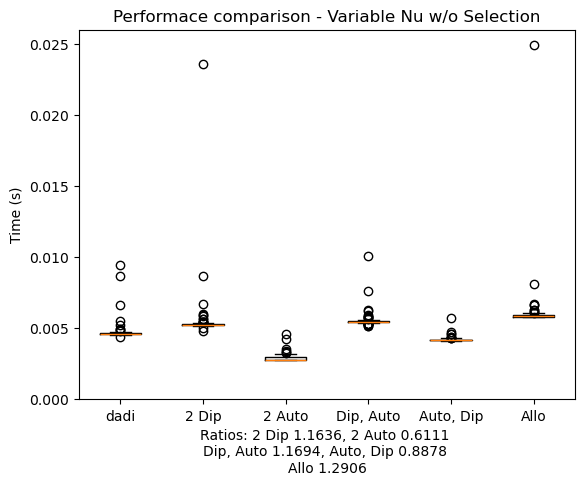

In [4]:
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx, gamma=0)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

dipflag = PolyInt.PloidyType.DIPLOID
autoflag = PolyInt.PloidyType.AUTO
alloaflag = PolyInt.PloidyType.ALLOa
allobflag = PolyInt.PloidyType.ALLOb
T = .1
gamma1 = 0
gamma2 = 0
h1 = 0.75
h2 = 0.25
m12 = .01
m21 = 0.1
sel_dip1 = {'gamma': gamma1, 'h': h1}
sel_dip2 = {'gamma': gamma2, 'h': h2}
sel_auto1 = {'gamma1': gamma1/4, 'gamma2': gamma1/2, 'gamma3': 3*gamma1/4, 'gamma4': gamma1}
sel_auto2 = {'gamma1': gamma2/4, 'gamma2': gamma2/2, 'gamma3': 3*gamma2/4, 'gamma4': gamma2}
sel_allo = {'gamma01': gamma2/4, 'gamma02': gamma2/2, 'gamma10': gamma2/4, 'gamma11': gamma2/2, 'gamma12': 3*gamma2/4, 'gamma20': gamma2/2, 'gamma21': 3*gamma2/4, 'gamma22': gamma2}
nu1 = 1.5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 3.0
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
iterations = 100

dadi_perf = np.empty(iterations)
poly_perf = np.empty(iterations)
auto_perf = np.empty(iterations)
dipauto_perf = np.empty(iterations)
autodip_perf = np.empty(iterations)
allo_perf = np.empty(iterations)
for i in range(iterations):
    start = time.perf_counter()
    phi = dadi.Integration.two_pops(phi.copy(), xx, T=T, theta0=1, gamma1=gamma1, gamma2=gamma2,h1=h1, h2=h2, 
                                    m12=m12, m21=m21, nu1=nu1_func, nu2=nu2_func)
    end = time.perf_counter()
    dadi_perf[i] = end - start
    
    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=dipflag, ploidyflag2=dipflag, sel_dict1=sel_dip1,
                           sel_dict2=sel_dip2, nu1=nu1_func, nu2=nu2_func, m12=m12, m21=m21)
    end = time.perf_counter()
    poly_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=autoflag, ploidyflag2=autoflag, sel_dict1=sel_auto1,
                           sel_dict2=sel_auto2, nu1=nu1_func, nu2=nu2_func, m12=m12, m21=m21)                      
    end = time.perf_counter()
    auto_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=dipflag, ploidyflag2=autoflag, sel_dict1=sel_dip1,
                           sel_dict2=sel_auto2, nu1=nu1_func, nu2=nu2_func, m12=m12, m21=m21)                      
    end = time.perf_counter()
    dipauto_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=autoflag, ploidyflag2=dipflag, sel_dict1=sel_auto1,
                           sel_dict2=sel_dip2, nu1=nu1_func, nu2=nu2_func, m12=m12, m21=m21)                      
    end = time.perf_counter()
    autodip_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=alloaflag, ploidyflag2=allobflag, sel_dict1=sel_allo,
                           sel_dict2=sel_allo, nu1=nu1_func, nu2=nu1_func, m12=m12, m21=m12)                      
    end = time.perf_counter()
    allo_perf[i] = end - start


# Plot boxplot of performance
performance = [dadi_perf, poly_perf, auto_perf, dipauto_perf, autodip_perf, allo_perf]

ratio_dip = np.mean(poly_perf)/np.mean(dadi_perf)
ratio_auto = np.mean(auto_perf)/np.mean(dadi_perf)
ratio_allo = np.mean(allo_perf)/np.mean(dadi_perf)
ratio_dipauto = np.mean(dipauto_perf)/np.mean(dadi_perf)
ratio_autodip = np.mean(autodip_perf)/np.mean(dadi_perf)

plt.boxplot(performance, tick_labels=['dadi', '2 Dip', '2 Auto', 'Dip, Auto', 'Auto, Dip', 'Allo'])
plt.title("Performace comparison - Variable Nu w/o Selection")
plt.ylabel("Time (s)")
plt.xlabel(f"Ratios: 2 Dip {ratio_dip:.4f}, 2 Auto {ratio_auto:.4f} \n"
           f"Dip, Auto {ratio_dipauto:.4f}, Auto, Dip {ratio_autodip:.4f} \n"
           f"Allo {ratio_allo:.4f}")
plt.ylim(ymin=0)

### Test Variable Nu with Selection

(0.0, 0.0956934007073869)

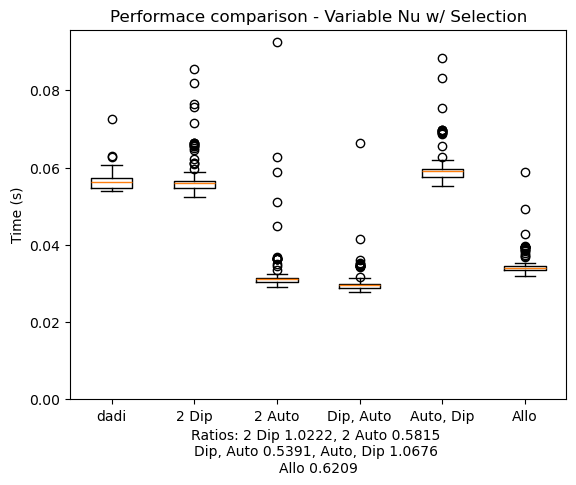

In [3]:
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx, gamma=-10, h=0.75)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)

dipflag = PolyInt.PloidyType.DIPLOID
autoflag = PolyInt.PloidyType.AUTO
alloaflag = PolyInt.PloidyType.ALLOa
allobflag = PolyInt.PloidyType.ALLOb
T = .1
gamma1 = -2
gamma2 = -10
h1 = 0.75
h2 = 0.25
m12 = .01
m21 = 0.1
sel_dip1 = {'gamma': gamma1, 'h': h1}
sel_dip2 = {'gamma': gamma2, 'h': h2}
sel_auto1 = {'gamma1': gamma1/4, 'gamma2': gamma1/2, 'gamma3': 3*gamma1/4, 'gamma4': gamma1}
sel_auto2 = {'gamma1': gamma2/4, 'gamma2': gamma2/2, 'gamma3': 3*gamma2/4, 'gamma4': gamma2}
sel_allo = {'gamma01': gamma2/4, 'gamma02': gamma2/2, 'gamma10': gamma2/4, 'gamma11': gamma2/2, 'gamma12': 3*gamma2/4, 'gamma20': gamma2/2, 'gamma21': 3*gamma2/4, 'gamma22': gamma2}
nu1 = 1.5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 3.0
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
iterations = 100

dadi_perf = np.empty(iterations)
poly_perf = np.empty(iterations)
auto_perf = np.empty(iterations)
dipauto_perf = np.empty(iterations)
autodip_perf = np.empty(iterations)
allo_perf = np.empty(iterations)
for i in range(iterations):
    start = time.perf_counter()
    phi = dadi.Integration.two_pops(phi.copy(), xx, T=T, theta0=1, gamma1=gamma1, gamma2=gamma2,h1=h1, h2=h2, 
                                    m12=m12, m21=m21, nu1=nu1_func, nu2=nu2_func)
    end = time.perf_counter()
    dadi_perf[i] = end - start
    
    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=dipflag, ploidyflag2=dipflag, sel_dict1=sel_dip1,
                           sel_dict2=sel_dip2, nu1=nu1_func, nu2=nu2_func, m12=m12, m21=m21)
    end = time.perf_counter()
    poly_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=autoflag, ploidyflag2=autoflag, sel_dict1=sel_auto1,
                           sel_dict2=sel_auto2, nu1=nu1_func, nu2=nu2_func, m12=m12, m21=m21)                      
    end = time.perf_counter()
    auto_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=dipflag, ploidyflag2=autoflag, sel_dict1=sel_dip1,
                           sel_dict2=sel_auto2, nu1=nu1_func, nu2=nu2_func, m12=m12, m21=m21)                      
    end = time.perf_counter()
    dipauto_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=autoflag, ploidyflag2=dipflag, sel_dict1=sel_auto1,
                           sel_dict2=sel_dip2, nu1=nu1_func, nu2=nu2_func, m12=m12, m21=m21)                      
    end = time.perf_counter()
    autodip_perf[i] = end - start

    start = time.perf_counter()
    phi = PolyInt.two_pops(phi.copy(), xx, T=T, ploidyflag1=alloaflag, ploidyflag2=allobflag, sel_dict1=sel_allo,
                           sel_dict2=sel_allo, nu1=nu1_func, nu2=nu1_func, m12=m12, m21=m12)                      
    end = time.perf_counter()
    allo_perf[i] = end - start


# Plot boxplot of performance
performance = [dadi_perf, poly_perf, auto_perf, dipauto_perf, autodip_perf, allo_perf]

ratio_dip = np.mean(poly_perf)/np.mean(dadi_perf)
ratio_auto = np.mean(auto_perf)/np.mean(dadi_perf)
ratio_allo = np.mean(allo_perf)/np.mean(dadi_perf)
ratio_dipauto = np.mean(dipauto_perf)/np.mean(dadi_perf)
ratio_autodip = np.mean(autodip_perf)/np.mean(dadi_perf)

plt.boxplot(performance, tick_labels=['dadi', '2 Dip', '2 Auto', 'Dip, Auto', 'Auto, Dip', 'Allo'])
plt.title("Performace comparison - Variable Nu w/ Selection")
plt.ylabel("Time (s)")
plt.xlabel(f"Ratios: 2 Dip {ratio_dip:.4f}, 2 Auto {ratio_auto:.4f} \n"
           f"Dip, Auto {ratio_dipauto:.4f}, Auto, Dip {ratio_autodip:.4f} \n"
           f"Allo {ratio_allo:.4f}")
plt.ylim(ymin=0)